In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import sys
import os
import joblib
from tqdm import tqdm
import networkx as nx
from scipy.spatial.distance import pdist, squareform

from ou_model import forward, backward, score, classify, theoretical_ts
from plotting import plot_speciation_3d, create_cont_sasne_animation, create_animated_embedding
from SASNE import SASNE
from RRP import RRP

from construct_graph import construct_graph # this comes from the SASNE repo
from adaptive_knn import AdaptiveKNNGraph # comes from graph-theory repo

### Toy example - small d and n

In [2]:
torch.manual_seed(123)
d = 2            # Dimension
nsamples_small_n = 6     # Number of trajectories
T_max = 10.0
dt = 0.01
times = np.arange(T_max, 0, -dt)

mu_star, std = torch.tensor([4.0, 4.0]), 1.0

In [3]:
small_n_path_history = []
# Start with pure random noise at t=T 
small_n_x_current = torch.randn(d, nsamples_small_n) 

for t in tqdm(times):
    small_n_path_history.append(small_n_x_current.T.clone().numpy()) 
    small_n_x_current, _ = backward(small_n_x_current, t, dt, mu_star, std)
    
small_n_path_history = np.array(small_n_path_history)

100%|███████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 22362.23it/s]


Since we can solve the score function analytically, we just need to sample using he backward process
The particles' starting point is the same, the trajectories will remain tangled until the end of the backward process. 
Once speciating takes place, the path commits to a class until the end of the reverse process.
It is at this point that the reverse process starts producing features of the same class. Since we know the exact form of the score function there is not a collapse time.

In [4]:
Lambda = np.linalg.norm(mu_star)**2 + std**2
t_s = np.log(Lambda) / 2
t_s_idx = next(idx for idx, t in enumerate(times) if round(t, 2) == round(t_s, 2))
print(t_s)

1.7482537641375833


#### Visualize trajectories

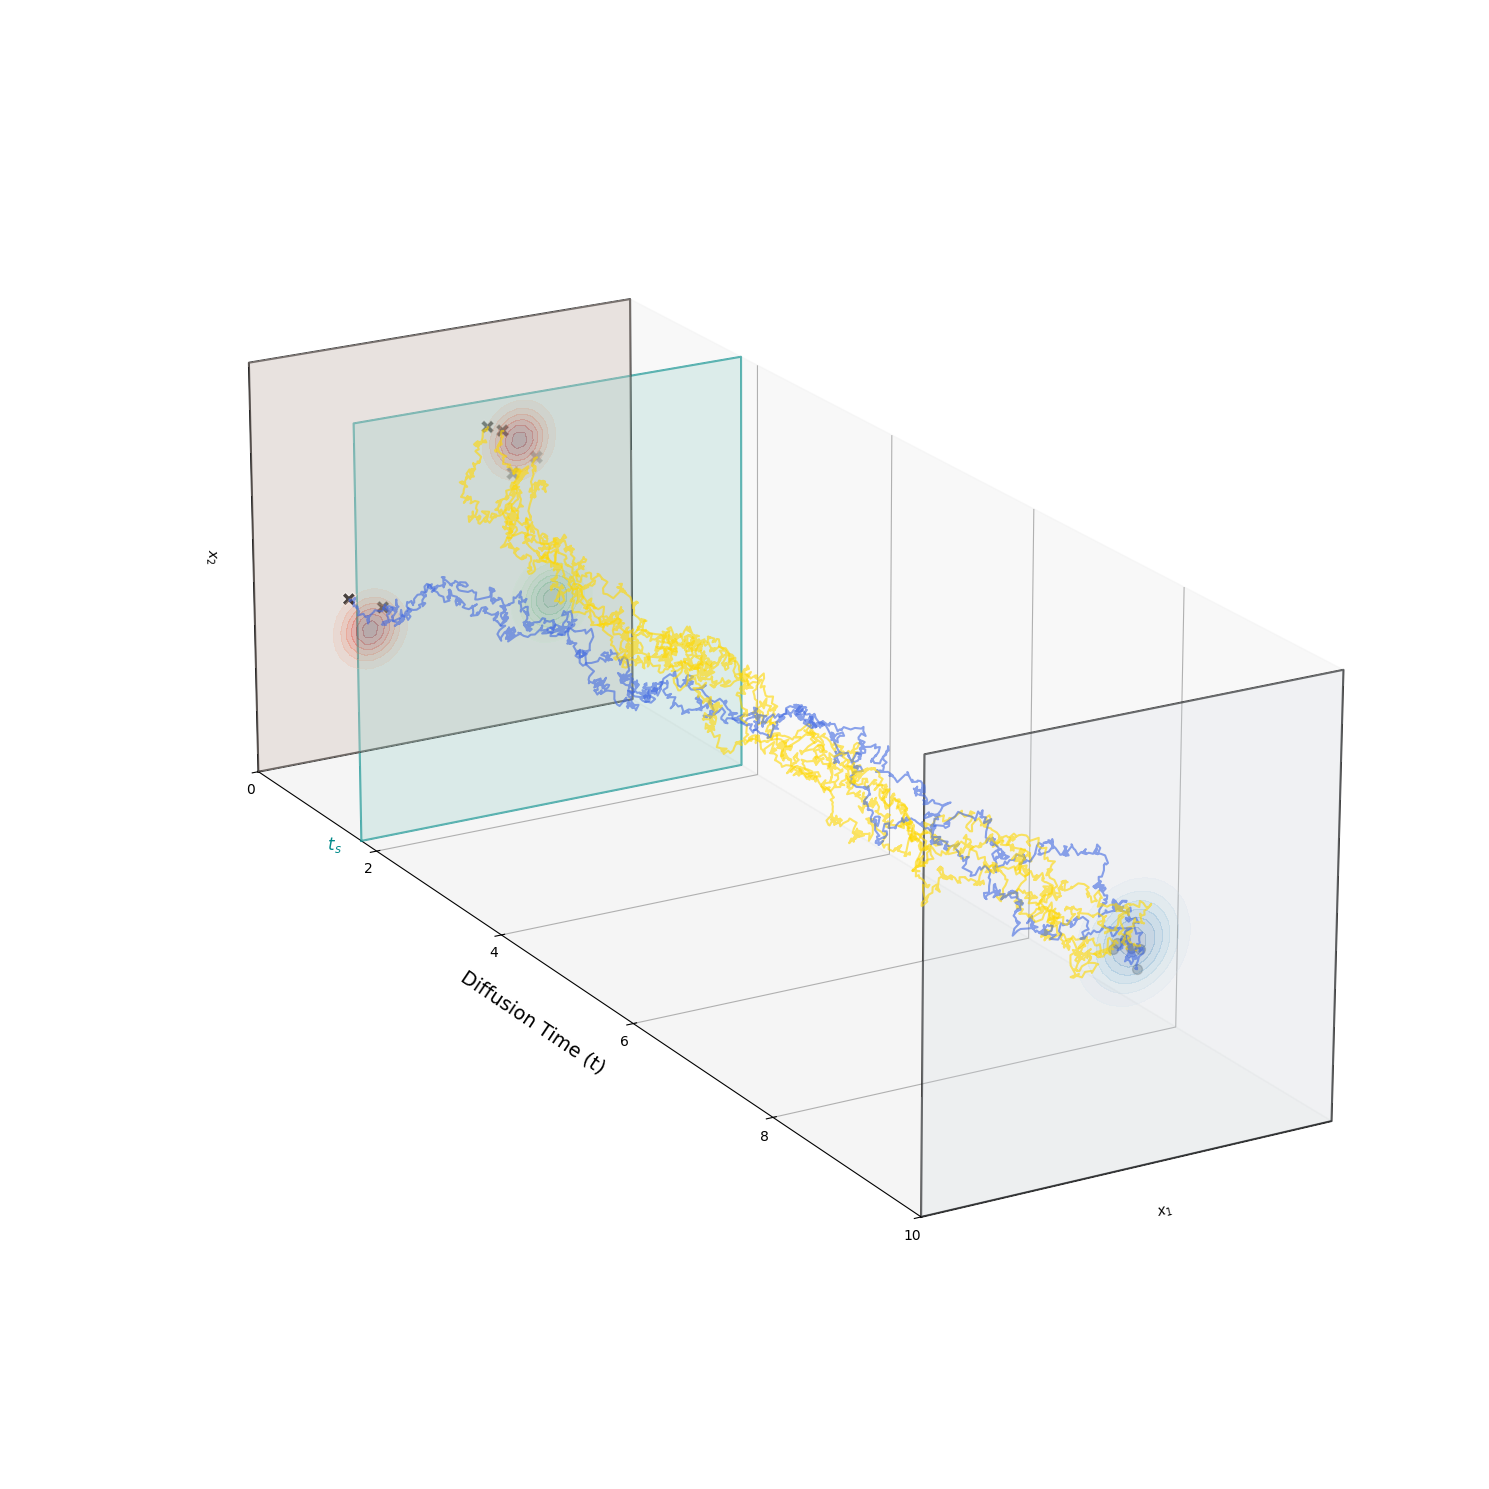

In [5]:
plot_speciation_3d(
    path_history=small_n_path_history,
    times=times,
    mu_star=mu_star,
    std=std,
    nsamples=nsamples_small_n,
    t_s=t_s,
    save_fig_path='../figures/diffusion_trajectories.png',
    t_c=None
)

### Knn graph from data at different time steps

In [6]:
loaded_data = joblib.load("../data/archive/D2_MU_4_N1000_100ts/D2_N1000.jbl")
large_n_path_history = loaded_data["history"]
tsm, ts_idx = theoretical_ts(mu_star, std, times)
X_T = torch.as_tensor(large_n_path_history[-1], dtype=mu_star.dtype).T
node_labels = classify(X_T, mu_star)
colors = node_labels.numpy().flatten()
knn_objs = []
for idx in [0, ts_idx, -1]:
    knn_obj = AdaptiveKNNGraph(large_n_path_history[idx], inject_edges=True, kernel='inverse_sq_euclidean_d')
    W = knn_obj.compute_W()
    k = knn_obj.k
    knn_objs.append((W, k))

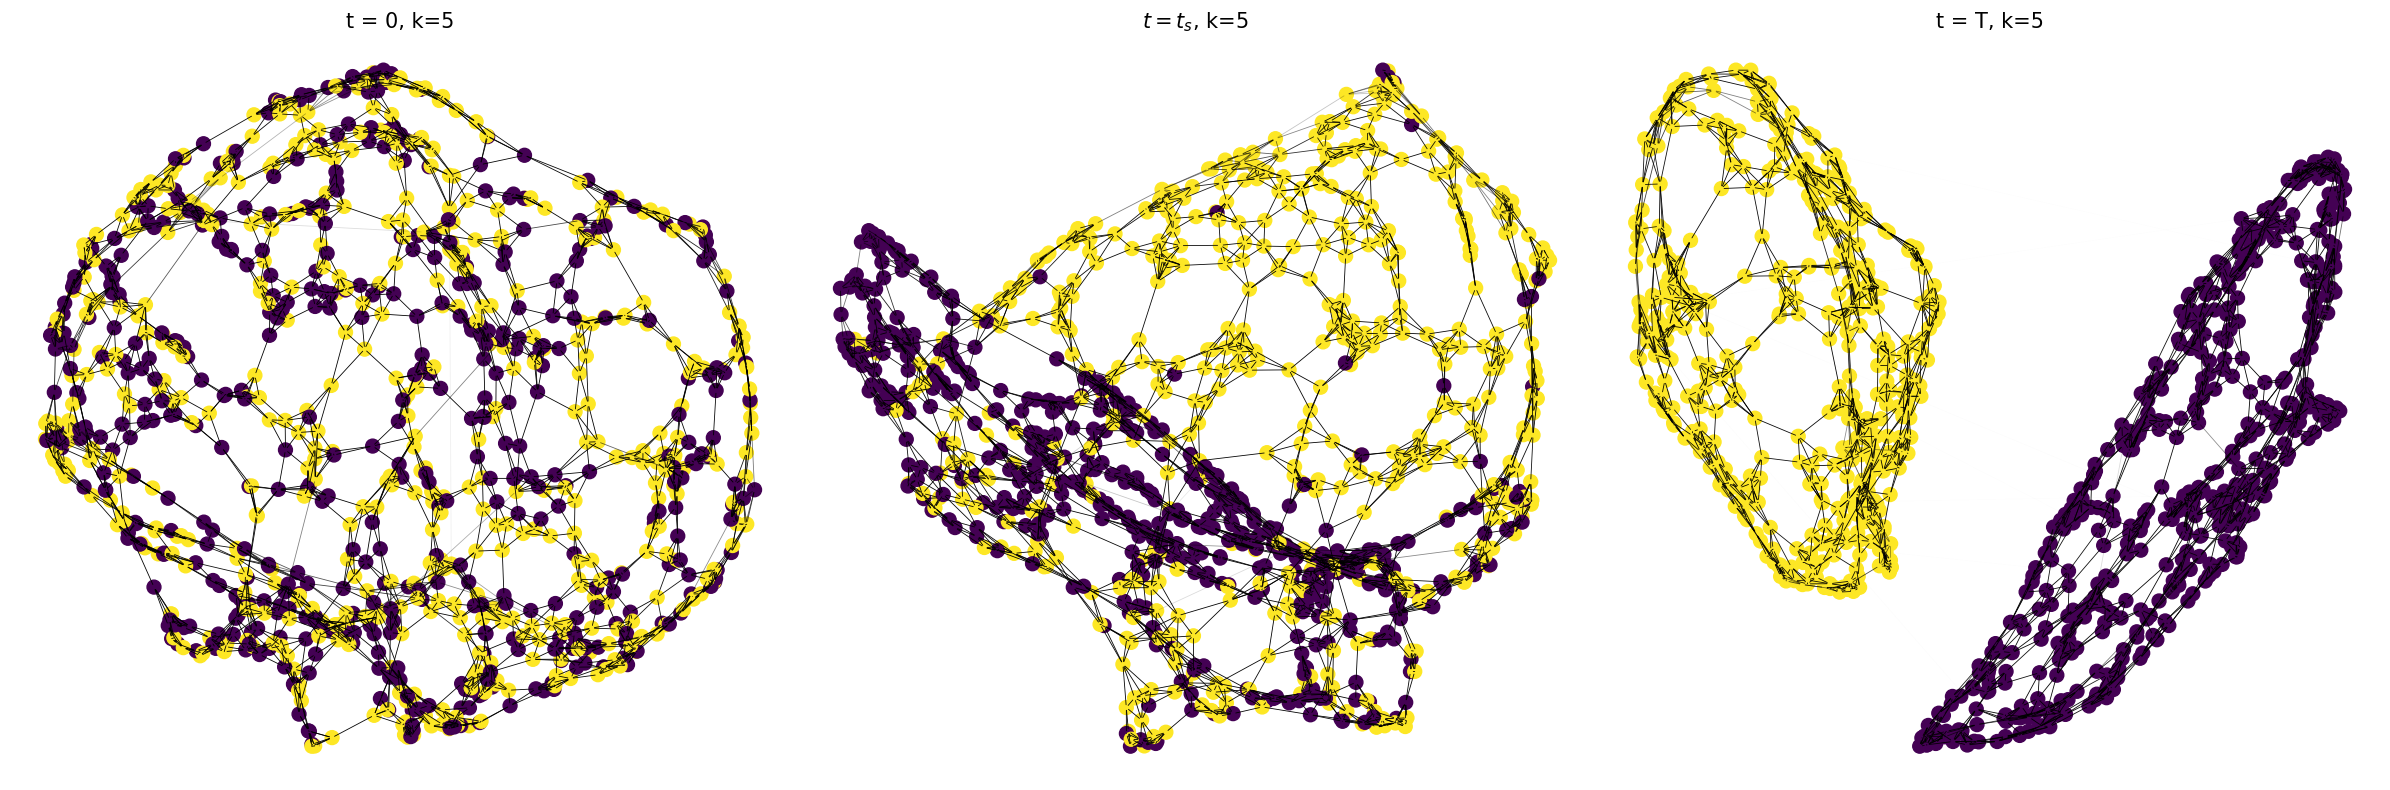

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
titles = ["t = 0", "$t = t_s$", "t = T"]
for i, obj in enumerate(knn_objs):
    W, k = obj
    G = nx.from_numpy_array(W)
    pos = nx.spring_layout(G, seed=42, k=0.15) 
    ax = axes[i]
    nx.draw_networkx_nodes(G, pos, node_size=100, node_color=colors, ax=ax)
    edges = G.edges(data=True)
    for u, v, d in edges:
        ax.annotate("", xy=pos[v], xycoords='data', xytext=pos[u], textcoords='data',
                    arrowprops=dict(arrowstyle="-", color="black", alpha=min(max(d['weight'], 0), 1),lw=0.6))
    ax.set_title(titles[i] + f", k={k}", fontsize=15)
    ax.axis('off')
plt.tight_layout()
plt.show()

### SASNE projection of the SAGS distance matrix for higher dimensions

In [6]:
sasne_embeddings_list = []
T = 10
nsteps = 1000
dt = T / nsteps
times = np.arange(0, T, dt)
d_list = [2, 256, 1024, 4096, 16384]
for d in d_list:
    print('d=', d)
    mu_star, std = torch.ones(d) * 4, 1.0
    loaded_data = joblib.load(f"../data/D{d}_N1000_100ts/D{d}_N1000.jbl")
    history = loaded_data["history"]
    times = loaded_data['params']['times']
    times_subset = loaded_data['params']['times_snapshots']
    t_s, ts_idx = theoretical_ts(mu_star, std, times)
    ts_idx = np.argmin(np.abs(times_subset - t_s))
    SAGD_dist_matrix = joblib.load(f"../data/D{d}_N1000_100ts/D{d}_N1000_SAGD.jbl")
    embedding, Z = SASNE(SAGD_dist_matrix)
    D1 = squareform(pdist(embedding)) 
    D2 = squareform(pdist(Z)) 
    sasne_embeddings_list.append((embedding, Z, D1, D2, ts_idx))
    print(' ')
    

d= 2
Constructing graph...
--- 0.00176 seconds elapsed ---
Computing graph distance...
--- 0.00526 seconds elapsed ---
Computing embedding...
--- 0.23725 seconds elapsed ---
 
d= 256
Constructing graph...
--- 0.00174 seconds elapsed ---
Computing graph distance...
--- 0.00377 seconds elapsed ---
Computing embedding...
--- 0.38585 seconds elapsed ---
 
d= 1024
Constructing graph...
--- 0.04611 seconds elapsed ---
Computing graph distance...
--- 0.00706 seconds elapsed ---
Computing embedding...
--- 0.25029 seconds elapsed ---
 
d= 4096
Constructing graph...
--- 0.04282 seconds elapsed ---
Computing graph distance...
--- 0.01895 seconds elapsed ---
Computing embedding...
--- 0.27102 seconds elapsed ---
 
d= 16384
Constructing graph...
--- 0.04323 seconds elapsed ---
Computing graph distance...
--- 0.0043 seconds elapsed ---
Computing embedding...
--- 0.2914 seconds elapsed ---
 


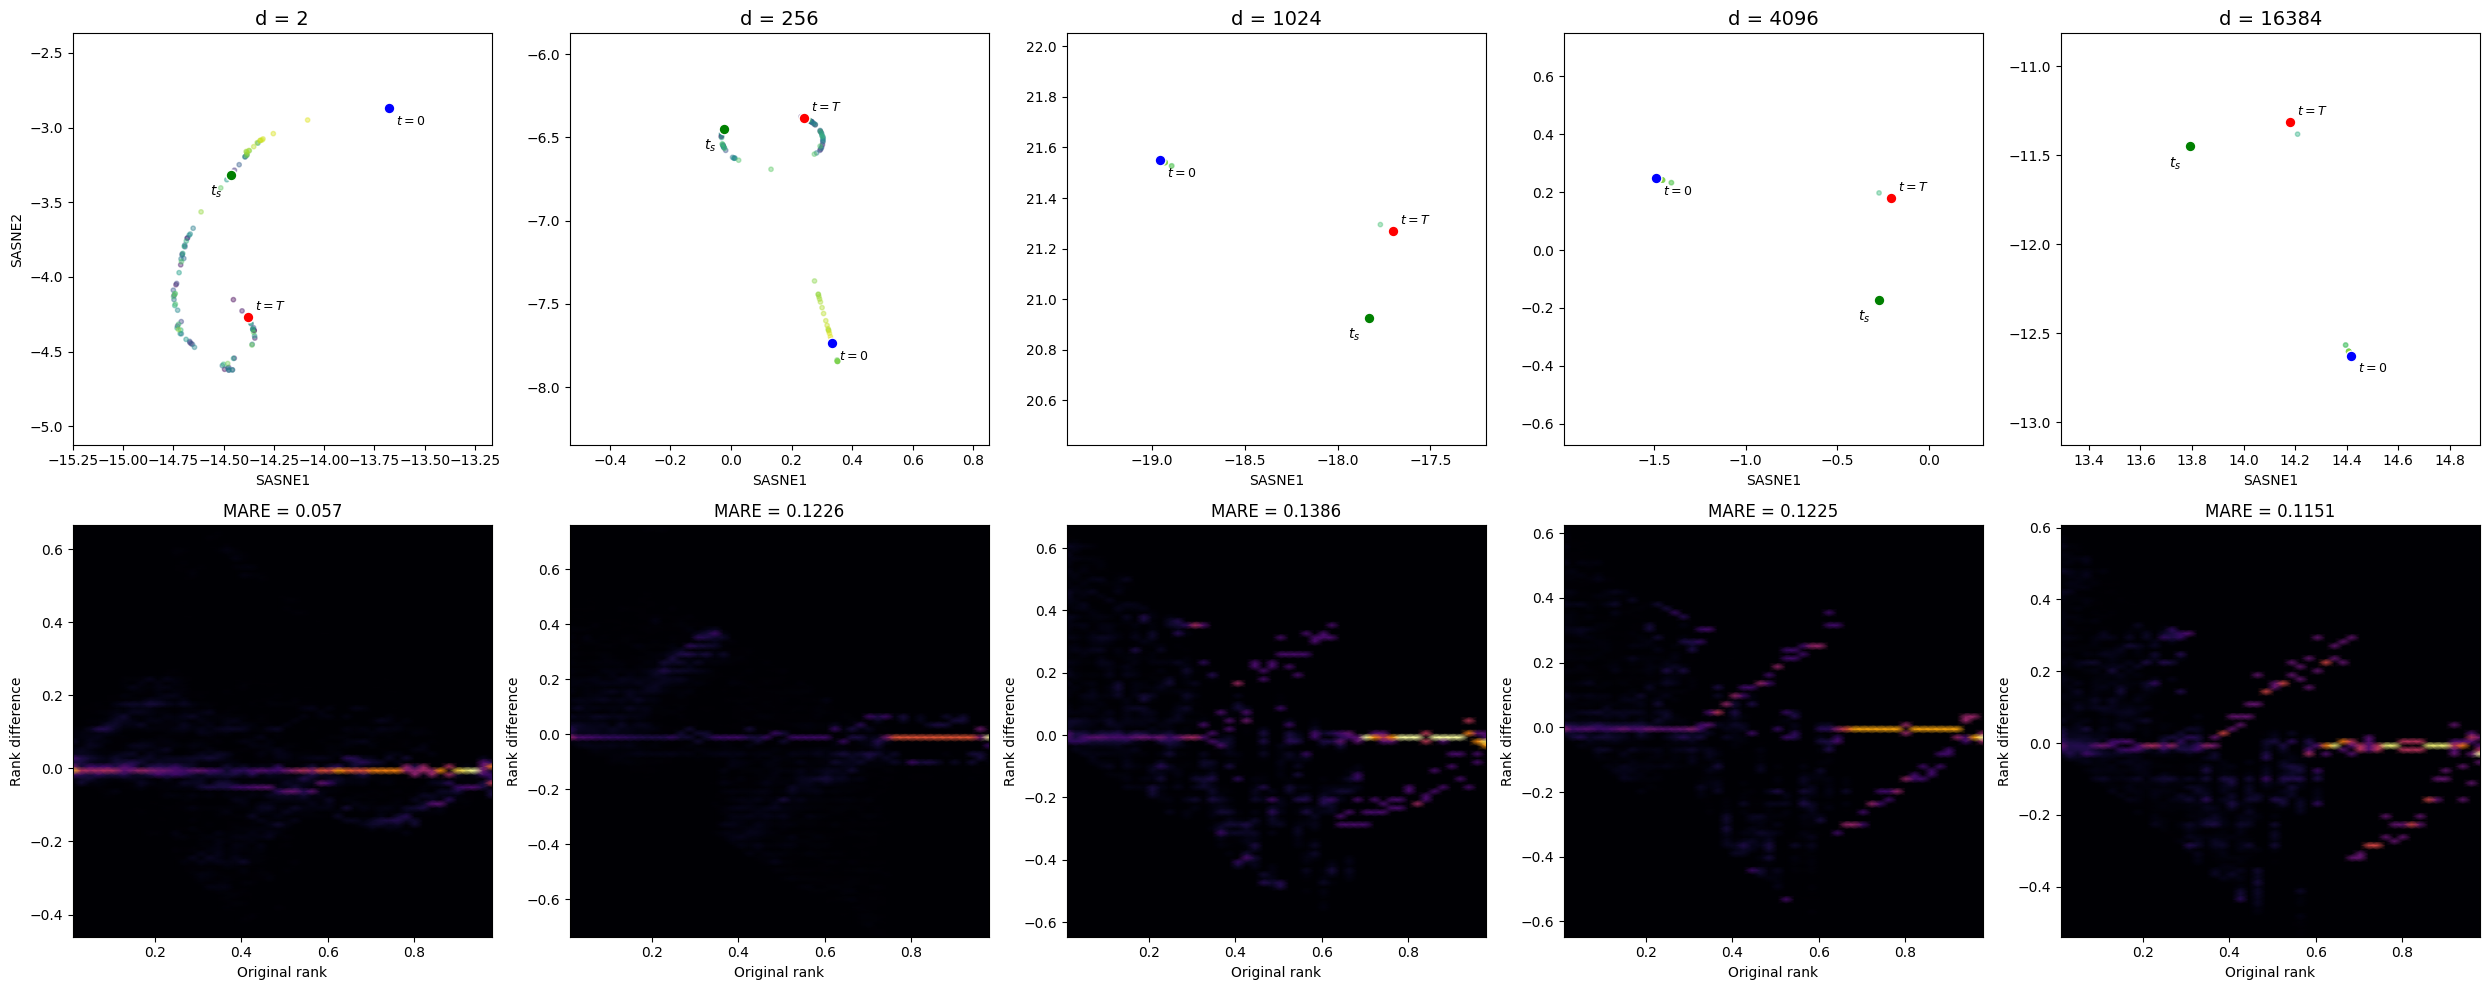

In [10]:
num_cols = len(d_list)
fig, axes = plt.subplots(2, num_cols, figsize=(5 * num_cols, 10))

if num_cols == 1:
    axes = axes.reshape(2, 1)

for i, (result, d) in enumerate(zip(sasne_embeddings_list, d_list)):
    embedding, Z, D1, D2, idx = result
    ax_proj = axes[0, i]
    ax_proj.set_title(f'd = {d}', fontsize=14)
    scatter = ax_proj.scatter(embedding[:, 0], embedding[:, 1], s=10, alpha=0.4, 
                               c=np.arange(len(embedding)), cmap='viridis')
    
    # 1. Start Point (Noise, t=T)
    ax_proj.scatter(embedding[0, 0], embedding[0, 1], c='red', s=60, 
                    edgecolors='white', zorder=5)
    ax_proj.annotate('$t=T$', xy=(embedding[0, 0], embedding[0, 1]), 
                     xytext=(5, 5), textcoords='offset points', fontsize=9)

    # 2. End Point (Data, t=0)
    ax_proj.scatter(embedding[-1, 0], embedding[-1, 1], c='blue', s=60, 
                    edgecolors='white', zorder=5)
    ax_proj.annotate('$t=0$', xy=(embedding[-1, 0], embedding[-1, 1]), 
                     xytext=(5, -12), textcoords='offset points', fontsize=9)

    # 3. Speciation Point (t_s)
    ax_proj.scatter(embedding[idx, 0], embedding[idx, 1], c='green', s=60,
                    edgecolors='white', zorder=6)
    ax_proj.annotate('$t_s$', xy=(embedding[idx, 0], embedding[idx, 1]), 
                     xytext=(-15, -15), textcoords='offset points')

    ax_proj.set_xlabel('SASNE1')
    if i == 0: ax_proj.set_ylabel('SASNE2')
    
    # Dynamic axis limits
    ax_proj.set_xlim(embedding[:, 0].min() - .5, embedding[:, 0].max() + .5)
    ax_proj.set_ylim(embedding[:, 1].min() - .5, embedding[:, 1].max() + .5)

    # --- ROW 2: Rank Resilience Plot (RRP) ---
    ax_rank = axes[1, i]
    plt.sca(ax_rank) 
    res = RRP(D1, D2) 
plt.tight_layout()
plt.savefig('../figures/dimension_sweep_results.png', dpi=300)
plt.show()

In [8]:
for result, d in zip(sasne_embeddings_list, d_list):
    embedding, _, _, _, ts_idx = result
    # save_path = f"../data/D{d}_N1000_100ts/diffusion_d{d}.gif"
    # create_animated_embedding(embedding, d, ts_idx, times_subset, save_path)
    save_path = f"../data/D{d}_N1000_100ts/diffusion_d{d}_v2.gif"
    create_cont_sasne_animation(embedding, times_subset, d, ts_idx, save_path)